# Customer Churn Prediction

**Machine Learning Classification Project**

This project predicts whether a customer is likely to churn using customer service and usage information.

## 1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("churn_dataset.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### 1.1 Data Overview

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(2666, 20)

Column Names:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Data Types:
State                         str
Account length              int64
Area code                   int64
International plan            str
Voice mail plan               str
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl 

In [4]:
# Statistical Summary
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


### 1.2 Data Quality Check

In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Duplicate Rows: 0


In [6]:
# Unique values in each column
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

State: 51 unique values
Account length: 205 unique values
Area code: 3 unique values
International plan: 2 unique values
Voice mail plan: 2 unique values
Number vmail messages: 42 unique values
Total day minutes: 1489 unique values
Total day calls: 115 unique values
Total day charge: 1489 unique values
Total eve minutes: 1442 unique values
Total eve calls: 120 unique values
Total eve charge: 1301 unique values
Total night minutes: 1444 unique values
Total night calls: 118 unique values
Total night charge: 885 unique values
Total intl minutes: 158 unique values
Total intl calls: 21 unique values
Total intl charge: 158 unique values
Customer service calls: 10 unique values
Churn: 2 unique values


### 1.3 Target Analysis

In [7]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
False    2278
True      388
Name: count, dtype: int64

Churn Percentage:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


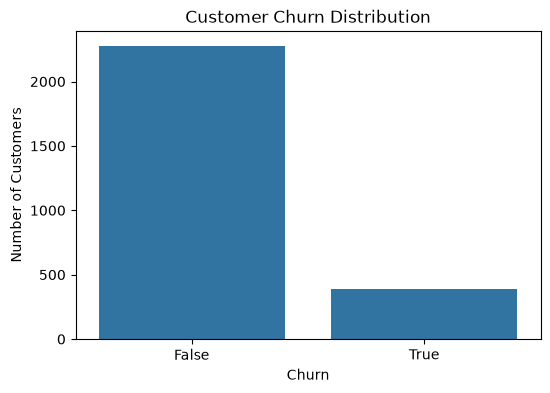

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### 1.4 Numerical Features vs Churn

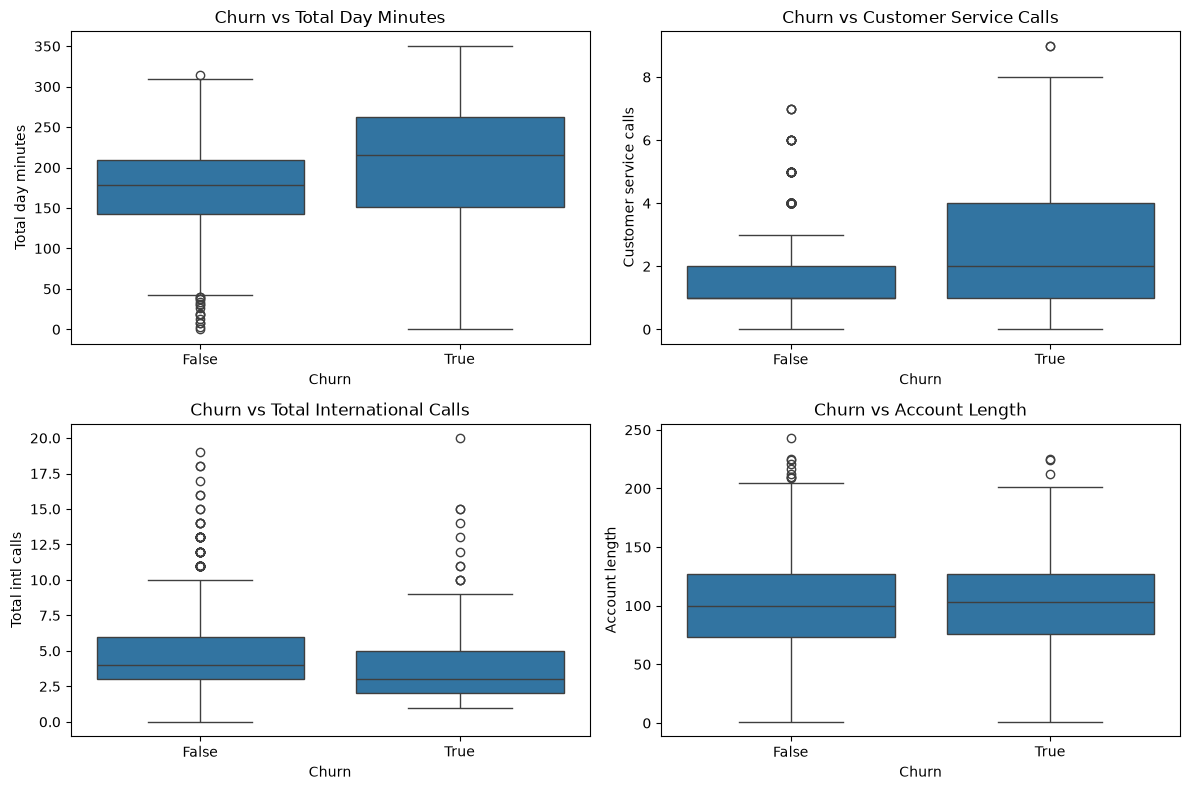

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x="Churn", y="Total day minutes", ax=axes[0, 0])
axes[0, 0].set_title("Churn vs Total Day Minutes")

sns.boxplot(data=df, x="Churn", y="Customer service calls", ax=axes[0, 1])
axes[0, 1].set_title("Churn vs Customer Service Calls")

sns.boxplot(data=df, x="Churn", y="Total intl calls", ax=axes[1, 0])
axes[1, 0].set_title("Churn vs Total International Calls")

sns.boxplot(data=df, x="Churn", y="Account length", ax=axes[1, 1])
axes[1, 1].set_title("Churn vs Account Length")

plt.tight_layout()
plt.show()

### 1.5 Categorical Features vs Churn

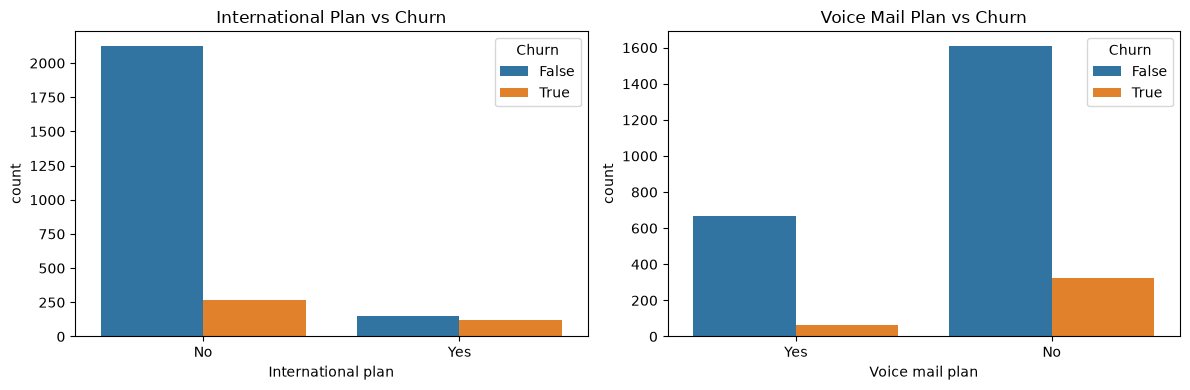

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="International plan", hue="Churn", ax=axes[0])
axes[0].set_title("International Plan vs Churn")

sns.countplot(data=df, x="Voice mail plan", hue="Churn", ax=axes[1])
axes[1].set_title("Voice Mail Plan vs Churn")

plt.tight_layout()
plt.show()

### 1.6 Correlation Analysis

In [11]:
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()
correlation

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
Account length,1.000000,-0.008620,-0.002996,0.002847,0.038862,0.002843,-0.015923,0.018552,-0.015909,-0.008994,-0.024007,-0.008999,0.011369,0.017627,0.011383,0.002455
Area code,-0.008620,1.000000,-0.000584,-0.023134,-0.009629,-0.023130,0.000679,-0.018602,0.000707,-0.003353,0.011455,-0.003382,-0.013418,-0.027423,-0.013534,0.034442
Number vmail messages,-0.002996,-0.000584,1.000000,0.019027,-0.009622,0.019027,0.011401,0.005131,0.011418,-0.000224,0.008124,-0.000229,-0.004156,0.027013,-0.004136,-0.018787
Total day minutes,0.002847,-0.023134,0.019027,1.000000,0.016780,1.000000,0.003999,0.009059,0.003992,0.013491,0.015054,0.013464,-0.011042,0.005687,-0.010934,-0.024543
Total day calls,0.038862,-0.009629,-0.009622,0.016780,1.000000,0.016787,-0.026003,0.006473,-0.026006,0.008986,-0.016776,0.008972,0.031036,0.006928,0.031133,-0.011945
Total day charge,0.002843,-0.023130,0.019027,1.000000,0.016787,1.000000,0.004008,0.009056,0.004002,0.013495,0.015057,0.013468,-0.011046,0.005688,-0.010938,-0.024548
Total eve minutes,-0.015923,0.000679,0.011401,0.003999,-0.026003,0.004008,1.000000,-0.007654,1.000000,-0.013414,0.009017,-0.013450,-0.006915,0.002160,-0.006947,-0.013192
Total eve calls,0.018552,-0.018602,0.005131,0.009059,0.006473,0.009056,-0.007654,1.000000,-0.007642,-0.000175,0.000797,-0.000135,0.011012,0.003710,0.011000,0.001058
Total eve charge,-0.015909,0.000707,0.011418,0.003992,-0.026006,0.004002,1.000000,-0.007642,1.000000,-0.013428,0.009030,-0.013464,-0.006923,0.002169,-0.006955,-0.013196
Total night minutes,-0.008994,-0.003353,-0.000224,0.013491,0.008986,0.013495,-0.013414,-0.000175,-0.013428,1.000000,0.012736,0.999999,-0.008607,-0.001110,-0.008510,0.005236


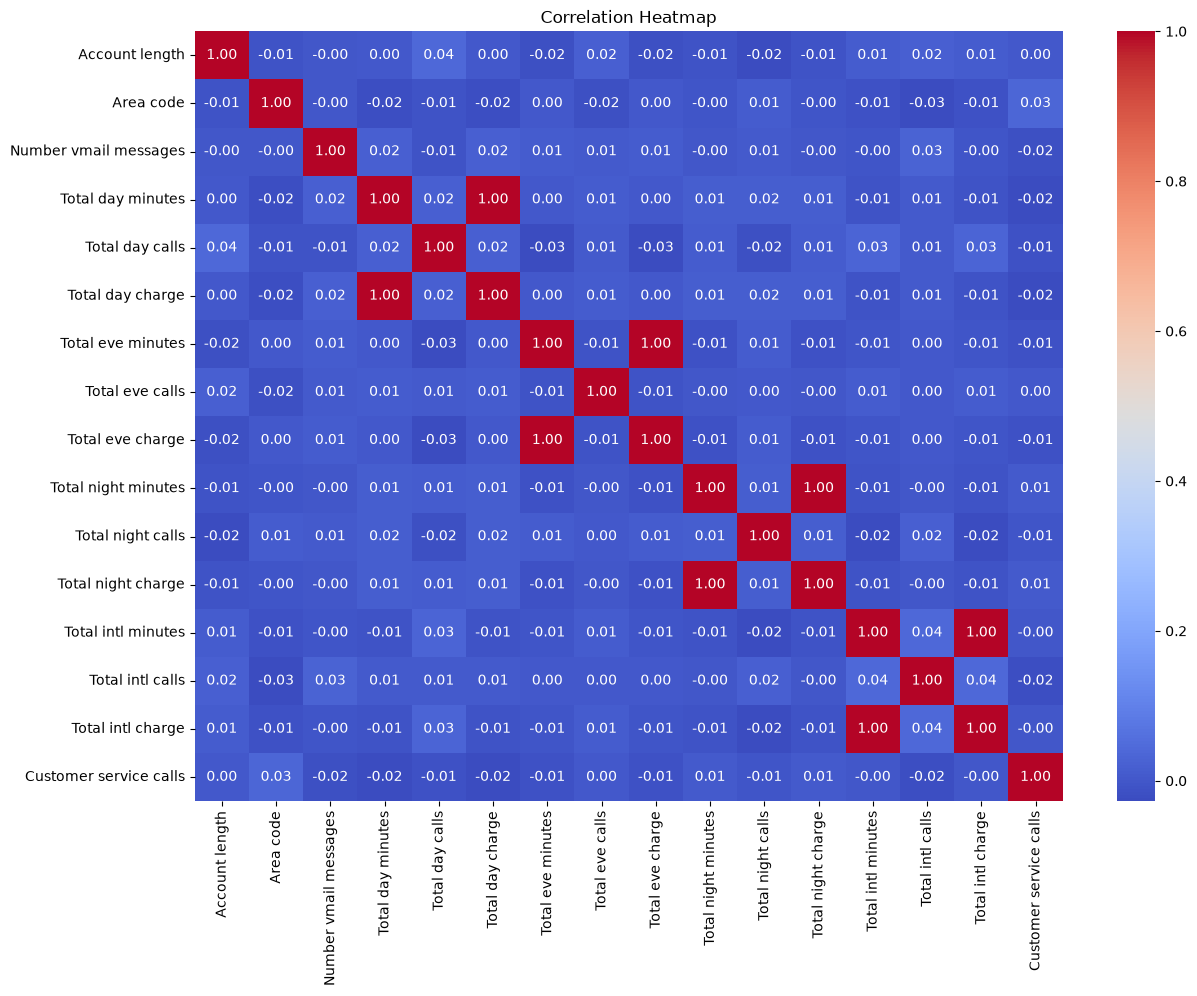

In [12]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 2. Data Preprocessing

In [13]:
# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)
df.head()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,...,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,International plan_Yes,Voice mail plan_Yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,...,False,False,False,False,False,False,False,False,False,True
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,...,False,False,False,False,False,False,False,False,False,True
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,...,False,False,False,False,False,False,False,False,False,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,...,False,False,False,False,False,False,False,False,True,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,...,False,False,False,False,False,False,False,False,True,False


In [14]:
# Define Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Baseline Model — Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.850187265917603
Precision: 0.4772727272727273
Recall: 0.2692307692307692
F1 Score: 0.3442622950819672
ROC-AUC: 0.7397379667116509

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.95      0.92       456
        True       0.48      0.27      0.34        78

    accuracy                           0.85       534
   macro avg       0.68      0.61      0.63       534
weighted avg       0.82      0.85      0.83       534



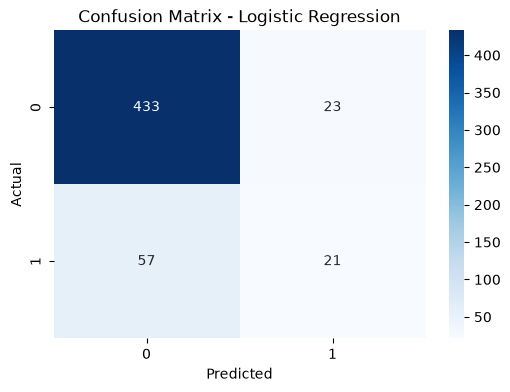

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

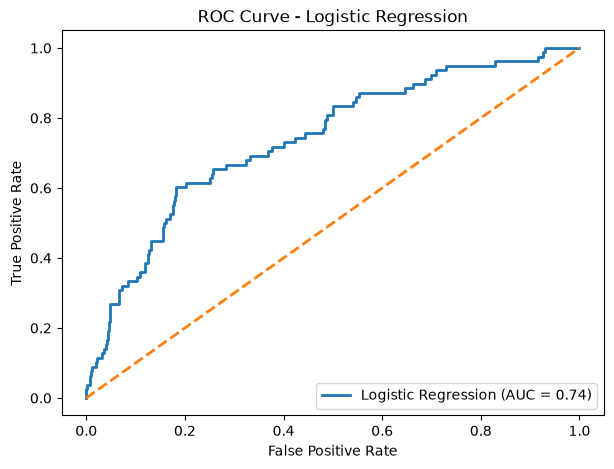

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

## 4. Handle Class Imbalance

In [21]:
balanced_logistic = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_logistic.fit(X_train_scaled, y_train)

y_pred_balanced = balanced_logistic.predict(X_test_scaled)
y_prob_balanced = balanced_logistic.predict_proba(X_test_scaled)[:, 1]

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1 Score:", f1_score(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7509363295880149
Precision: 0.31788079470198677
Recall: 0.6153846153846154
F1 Score: 0.4192139737991266
ROC-AUC: 0.7422964462438146

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.77      0.84       456
        True       0.32      0.62      0.42        78

    accuracy                           0.75       534
   macro avg       0.62      0.69      0.63       534
weighted avg       0.83      0.75      0.78       534



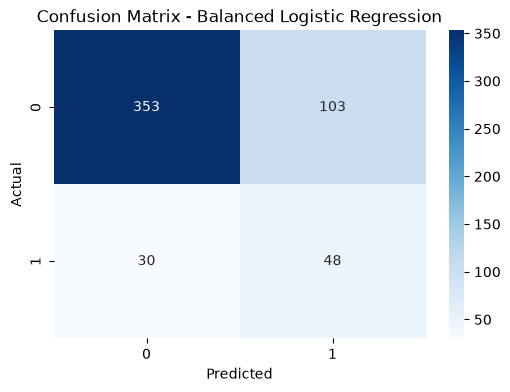

In [23]:
cm = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 5. Model Comparison

In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

random_forest = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced"
)

gradient_boosting = GradientBoostingClassifier(random_state=42)

random_forest.fit(X_train, y_train)
gradient_boosting.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

gb_pred = gradient_boosting.predict(X_test)
gb_prob = gradient_boosting.predict_proba(X_test)[:, 1]

In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_balanced),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.850187,0.477273,0.269231,0.344262,0.739738
1,Balanced Logistic Regression,0.750936,0.317881,0.615385,0.419214,0.742296
2,Random Forest,0.947566,0.878788,0.743590,0.805556,0.891644
3,Gradient Boosting,0.940075,0.848485,0.717949,0.777778,0.873819


## 6. Cross Validation

In [26]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

In [27]:
cv_logistic = cross_validate(
    balanced_logistic, X_train_scaled, y_train, cv=cv, scoring=scoring
)

print("Balanced Logistic Regression")
print("Accuracy:", cv_logistic["test_accuracy"].mean())
print("Precision:", cv_logistic["test_precision"].mean())
print("Recall:", cv_logistic["test_recall"].mean())
print("F1:", cv_logistic["test_f1"].mean())
print("ROC-AUC:", cv_logistic["test_roc_auc"].mean())

Balanced Logistic Regression
Accuracy: 0.764082857802553
Precision: 0.3419401292647621
Recall: 0.6774193548387097
F1: 0.45391888885367077
ROC-AUC: 0.8002075189503381


In [28]:
cv_rf = cross_validate(
    random_forest, X_train, y_train, cv=cv, scoring=scoring
)

print("Random Forest")
print("Accuracy:", cv_rf["test_accuracy"].mean())
print("Precision:", cv_rf["test_precision"].mean())
print("Recall:", cv_rf["test_recall"].mean())
print("F1:", cv_rf["test_f1"].mean())
print("ROC-AUC:", cv_rf["test_roc_auc"].mean())

Random Forest
Accuracy: 0.9413695286472936
Precision: 0.8351092137122468
Recall: 0.7419354838709677
F1: 0.7843742217920354
ROC-AUC: 0.9217490761558371


In [29]:
cv_gb = cross_validate(
    gradient_boosting, X_train, y_train, cv=cv, scoring=scoring
)

print("Gradient Boosting")
print("Accuracy:", cv_gb["test_accuracy"].mean())
print("Precision:", cv_gb["test_precision"].mean())
print("Recall:", cv_gb["test_recall"].mean())
print("F1:", cv_gb["test_f1"].mean())
print("ROC-AUC:", cv_gb["test_roc_auc"].mean())

Gradient Boosting
Accuracy: 0.9493375553869665
Precision: 0.8907377417903735
Recall: 0.7419354838709677
F1: 0.808332710936029
ROC-AUC: 0.9257663778996081


## 7. Hyperparameter Tuning — Random Forest

In [30]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)
print("\nBest Cross-Validation ROC-AUC:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross-Validation ROC-AUC:
0.9186230715815338


## 8. Final Model Evaluation

In [31]:
best_model = rf_grid.best_estimator_

final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(X_test)[:, 1]

In [32]:
print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1 Score:", f1_score(y_test, final_pred))
print("ROC-AUC:", roc_auc_score(y_test, final_prob))
print("\nClassification Report:")
print(classification_report(y_test, final_pred))

Accuracy: 0.9176029962546817
Precision: 0.7073170731707317
Recall: 0.7435897435897436
F1 Score: 0.725
ROC-AUC: 0.8774741340530815

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.95      0.95       456
        True       0.71      0.74      0.72        78

    accuracy                           0.92       534
   macro avg       0.83      0.85      0.84       534
weighted avg       0.92      0.92      0.92       534



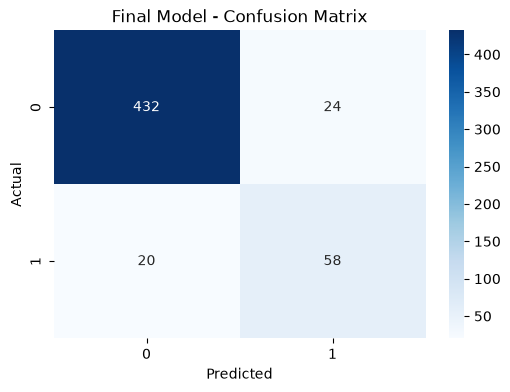

In [33]:
final_cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(final_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

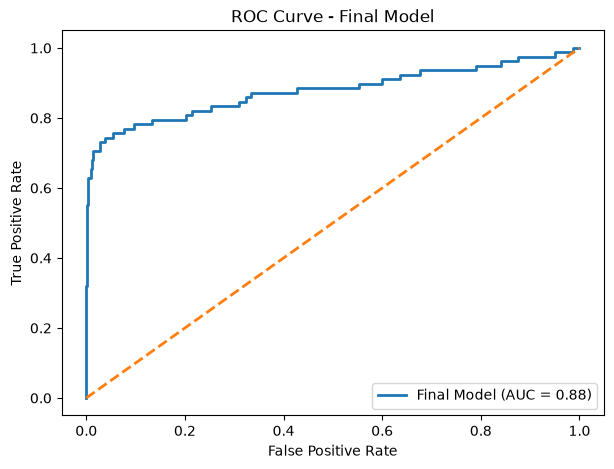

In [34]:
final_fpr, final_tpr, final_thresholds = roc_curve(y_test, final_prob)
final_auc = auc(final_fpr, final_tpr)

plt.figure(figsize=(7, 5))
plt.plot(final_fpr, final_tpr, lw=2, label=f"Final Model (AUC = {final_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend(loc="lower right")
plt.show()

## 9. Threshold Optimization

In [35]:
thresholds_to_test = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

threshold_results = []

for threshold in thresholds_to_test:
    custom_pred = (final_prob >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, custom_pred),
        "Recall": recall_score(y_test, custom_pred),
        "F1": f1_score(y_test, custom_pred)
    })

threshold_results = pd.DataFrame(threshold_results)
threshold_results

,Threshold,Precision,Recall,F1
0,0.50,0.707317,0.743590,0.725000
1,0.45,0.655556,0.756410,0.702381
2,0.40,0.576923,0.769231,0.659341
3,0.35,0.480620,0.794872,0.599034
4,0.30,0.407895,0.794872,0.539130
5,0.25,0.340314,0.833333,0.483271
6,0.20,0.230769,0.884615,0.366048


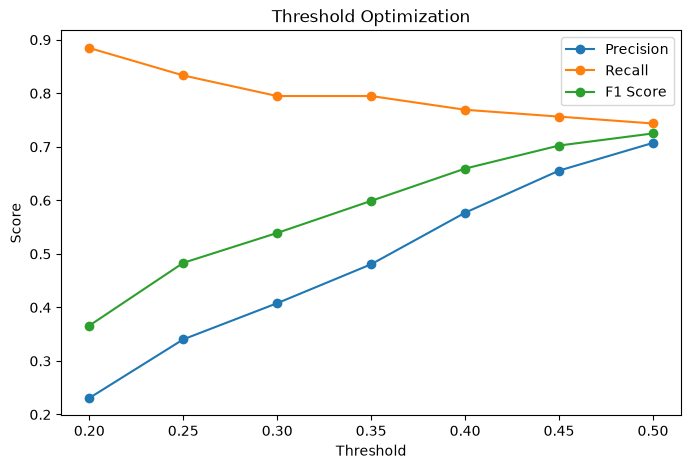

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], marker="o", label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], marker="o", label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1"], marker="o", label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.show()

## 10. Feature Importance

In [37]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
15,Customer service calls,0.148869
5,Total day charge,0.137860
3,Total day minutes,0.134635
66,International plan_Yes,0.100507
8,Total eve charge,0.044616
6,Total eve minutes,0.043284
12,Total intl minutes,0.040223
14,Total intl charge,0.036265
13,Total intl calls,0.031991
11,Total night charge,0.030938


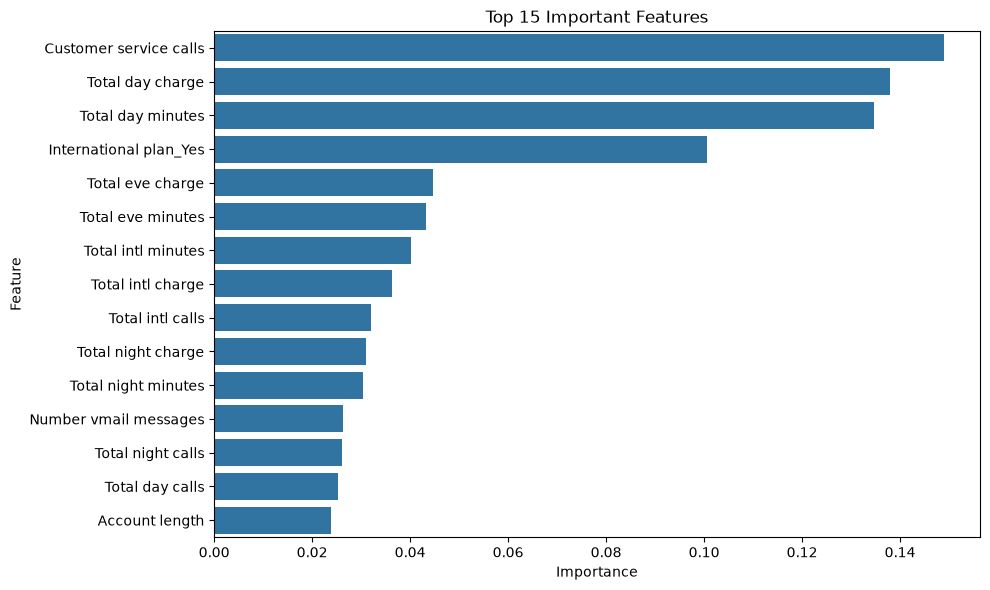

In [38]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 11. Save Model and Results

In [39]:
import joblib

joblib.dump(best_model, "customer_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
results.to_csv("model_comparison_results.csv", index=False)
threshold_results.to_csv("threshold_results.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)

## 12. Example Prediction

In [41]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0, 1]

print("Prediction:", prediction)
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: False
Churn Probability: 16.24 %


## 13. Conclusion

In [42]:
print("Customer Churn Prediction Project Completed!")
print(f"Final ROC-AUC: {final_auc:.3f}")
print(f"Final Accuracy: {accuracy_score(y_test, final_pred):.3f}")
print(f"Final Precision: {precision_score(y_test, final_pred):.3f}")
print(f"Final Recall: {recall_score(y_test, final_pred):.3f}")
print(f"Final F1 Score: {f1_score(y_test, final_pred):.3f}")

Customer Churn Prediction Project Completed!
Final ROC-AUC: 0.877
Final Accuracy: 0.918
Final Precision: 0.707
Final Recall: 0.744
Final F1 Score: 0.725
